In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Ventas simuladas de productos A a F
np.random.seed(42)  # Semilla para obtener siempre los mismos resultados

IVA = 0.21  # Tipo de IVA del 21 %

ventas = pd.DataFrame({
    "producto": ["A", "B", "C", "D", "E", "F"],
    "departamento": ["Electrónica", "Electrónica", "Ropa", "Ropa", "Alimentos", "Alimentos"],
    "precio_sin_iva": np.round(np.random.uniform(5, 500, 6), 2),
    "unidades": np.random.randint(10, 100, 6),
})

# Cálculo del IVA y del precio final
ventas["iva"] = (ventas["precio_sin_iva"] * IVA).round(2)
ventas["precio_con_iva"] = ventas["precio_sin_iva"] + ventas["iva"]
ventas["total_ventas"] = (ventas["precio_con_iva"] * ventas["unidades"]).round(2)

ventas

,producto,departamento,precio_sin_iva,unidades,iva,precio_con_iva,total_ventas
0,A,Electrónica,190.40,84,39.98,230.38,19351.92
1,B,Electrónica,475.60,84,99.88,575.48,48340.32
2,C,Ropa,367.34,97,77.14,444.48,43114.56
3,D,Ropa,301.34,33,63.28,364.62,12032.46
4,E,Alimentos,82.23,12,17.27,99.50,1194.00
5,F,Alimentos,82.22,31,17.27,99.49,3084.19


In [3]:
df_ventas = pd.DataFrame(ventas)
print(df_ventas)

  producto departamento  precio_sin_iva  unidades    iva  precio_con_iva  \
0        A  Electrónica          190.40        84  39.98          230.38   
1        B  Electrónica          475.60        84  99.88          575.48   
2        C         Ropa          367.34        97  77.14          444.48   
3        D         Ropa          301.34        33  63.28          364.62   
4        E    Alimentos           82.23        12  17.27           99.50   
5        F    Alimentos           82.22        31  17.27           99.49   

   total_ventas  
0      19351.92  
1      48340.32  
2      43114.56  
3      12032.46  
4       1194.00  
5       3084.19  


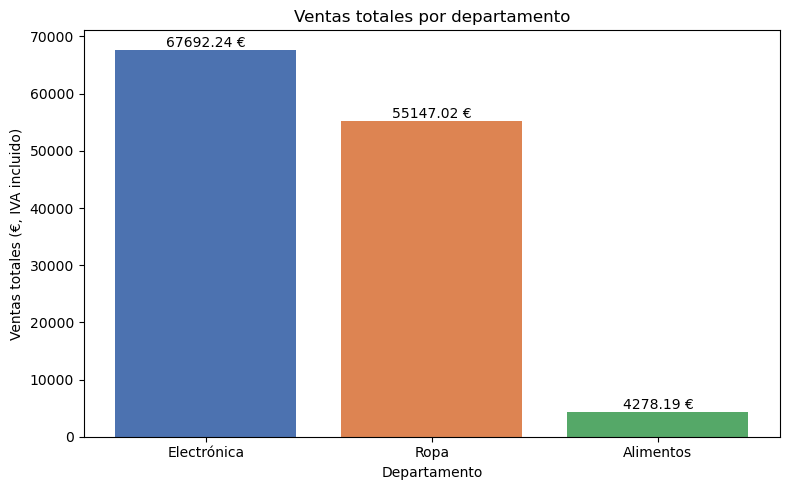

In [4]:
# Gráfico de barras: ventas totales por departamento
ventas_por_departamento = df_ventas.groupby("departamento")["total_ventas"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(ventas_por_departamento.index, ventas_por_departamento.values, color=["#4C72B0", "#DD8452", "#55A868"])

ax.set_title("Ventas totales por departamento")
ax.set_xlabel("Departamento")
ax.set_ylabel("Ventas totales (€, IVA incluido)")
ax.bar_label(barras, fmt="%.2f €")  # Muestra el valor encima de cada barra

plt.tight_layout()
plt.show()